<a href="https://colab.research.google.com/github/Mahdi79-physics/BlueQuBit_PeakedCircuit/blob/main/Copy_of_HW3_VisionLanguageModel_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installation



در این بخش کتابخانه‌ها و تنظیمات اینوایرومتی که برای این پروژه نیاز هست قرار گرفته است. این سلول کد را بدون تغییر اجرا کنید

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

### Unsloth

در این بخش مدل زبانی که میخواهیم آموزش دهیم را انتخاب میکنیم. برای این پروژه مدل های 4 بیت را انتخاب میکنیم. مدل های زبانی دارای پارامتر‌ها زیادی هستند تعداد پارامترهای آنها در مقیاس میلیارد می‌باشد. آموزش این مدل‌ها حجم کارت گرافیکی زیادی مصرف می‌کنند و آموزش آنها در سیستم های رایگان گوگل کلب ممکن نیست.


برای این تمرین مدل زیراستفاده می‌شود.
```
unsloth/Qwen2-VL-2B-Instruct-bnb-4bit
```

در این سلول بخش‌‌هایی از کد قرار داده شده است و بقیه بخش های کد باید توسط شما کامل شود. در این بخش باید پارامترهایی مشخص بشوند که موارد زیر انجام شود.




*   مدل گفته شده لود شود.
*   مدل در حالت 4 بیت لود شود.
*   برای آموزش سریع تر و کاهش مموری گرافیک استفاده شده از گرادیان چک پوینت خود unsloth استفاده شود.





In [2]:
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

==((====))==  Unsloth 2026.6.7: Fast Qwen2_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


در این بخش برای کاهش  میزان حجم گرافیک استفاده شده. از روش اضافه کردن آداپتور استفاده میکنم. در این روش وزن‌های اصلی مدل فریز می‌شود و وزن های لورا به صورت موازی با وزن‌های مدل قرار میگیرد و آنها که به مراتب کوچک‌تر از وزن‌های اصلی می‌باشد آموزش داده می‌شود. در نهایت با وزن‌های اصلی مرج می‌شود.



در این سلول بخش‌هایی کامل شده است و آرگویمت های آنها را شما باید کامل کنید. موارد زیر حتما باید مشخص کنید.

*   مدل انتخاب شده
*   مشخص کردن اینکه وزن‌های لورا به کدام بخش‌های مدل متصل شوند.
*   مشخص کردن پارامتر‌های وزن های لورا



In [3]:
model = FastVisionModel.get_peft_model(
    ## Complete here
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",

    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

<a name="Data"></a>
### Data Prep


دراین بخش دیتاست زیر را دانلود کرده و به فرمت خواسته شده تبدیل کنید.
اسم دیتاست:
```
# unsloth/Radiology_mini
```
فرمت مورد نظر:
برای تبدیل به فرمت زیر یک تابع بنویسید که اینکارا انجام دهد.

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": instruction}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": answer} ]
},
]
```

همچنین یک نمونه از عکس و کپشن عکس را نمایش دهید.



In [4]:
from datasets import load_dataset

dataset = load_dataset("unsloth/Radiology_mini")
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [5]:
def convert_to_conversation(sample):
    instruction = (
        "Analyze this radiology image and generate a detailed medical report."
    )

    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": instruction},
                    {"type": "image", "image": sample["image"]},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": sample["caption"]},
                ],
            },
        ]
    }

In [6]:
converted_train = [
    convert_to_conversation(sample)
    for sample in train_dataset
]

converted_test = [
    convert_to_conversation(sample)
    for sample in test_dataset
]

In [7]:
print(type(converted_train[0]))
print(converted_train[0].keys())

<class 'dict'>
dict_keys(['messages'])


In [8]:
print(converted_train[0])

{'messages': [{'role': 'user', 'content': [{'type': 'text', 'text': 'Analyze this radiology image and generate a detailed medical report.'}, {'type': 'image', 'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=657x442 at 0x77FAD6572AB0>}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Panoramic radiography shows an osteolytic lesion in the right posterior maxilla with resorption of the floor of the maxillary sinus (arrows).'}]}]}


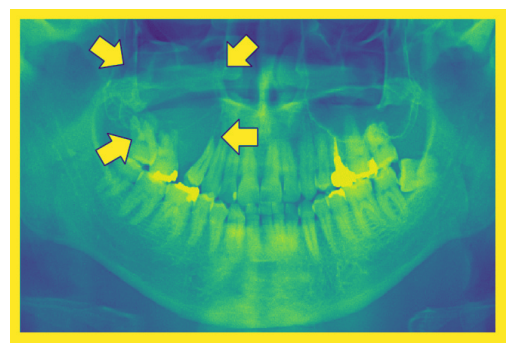

Caption:
Panoramic radiography shows an osteolytic lesion in the right posterior maxilla with resorption of the floor of the maxillary sinus (arrows).


In [9]:
import matplotlib.pyplot as plt

sample = train_dataset[0]

plt.imshow(sample["image"])
plt.axis("off")
plt.show()

print("Caption:")
print(sample["caption"])

In [10]:
converted_train[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Analyze this radiology image and generate a detailed medical report.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=657x442>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'Panoramic radiography shows an osteolytic lesion in the right posterior maxilla with resorption of the floor of the maxillary sinus (arrows).'}]}]}

**نمایش نمونه خروجی**

برای مقایسه عملکرد این مدل ابتدا از مدل قبل از آموزش خروجی میگیریم. در این حالت مدل آموزش پیدا نکرده است و خروجی های دقیقی به ما نمی‌دهد.  این خروجی را با مدل نهایی بعد از تیون شدن مقایسه کنید. و باید دقت خروجی نهایی شما افزایش پیدا کرده باشد.

**کد‌های این بخش**


برای این بخش باید موارد زیر را کامل کنید.


*   یک نمونه عکس را با پرامت داده شده به مدل بدهید.
*   فرمت پیام را مانند بخش زیر کامل کنید.
*   بخش تولید متن مدل را کامل کنید.






In [11]:
FastVisionModel.for_inference(model) # Enable for inference!

sample = train_dataset[0]

image =   sample["image"]  # Complete Here ...
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
  {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": instruction},
        ],
    }
  # Complete Here ....
]


input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate( **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True, )

/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

This image is a panoramic dental X-ray showing a panoramic view of the oral cavity. The arrows indicate specific areas of interest:

1. **Upper Left Area**: The arrow points to the area around the upper left molar teeth.
2. **Upper Right Area**: The arrow points to the area around the upper right molar teeth.
3. **Lower Left Area**: The arrow points to the area around the lower left molar teeth.
4. **Lower Right Area**: The arrow points to the area around the lower right molar teeth.

The panoramic X-ray provides a comprehensive view of the teeth and surrounding structures, including the jawbone


<a name="Train"></a>
### Train the model


در این بخش مدل آموزش داده می‌شود بخش های خواسته شده را کامل کنید.

In [13]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_train, #complete here ... ,
    args = SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        warmup_steps=5,
        max_steps=35,

        learning_rate=2e-4,

        fp16=True,
        bf16=False,

        logging_steps=1,

        optim="adamw_8bit",

        weight_decay=0.01,

        lr_scheduler_type="linear",

        seed=3407,

        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},

        report_to="none",   # Complete Here...
    ),
)

Unsloth: Model does not have a default image size - using 512


**آموزش مدل**

در این قسمت مدل با هایپر پارامترهایی که در بخش قبل انتخاب کردید آموزش داده میشود. مدل میتواند زمان زیادی آموزش داده شود اما آموزش زیاد با توجه به کوچک بودن دیتاست خطر اورفیت شدن مدل را دارد. برای این پروژه هدف رسیدن به ترینیگ لاس کمتر از 1 میباشد. شما باید هایپر پارامترها را به گونه ای تایین کنید که به لاس کمتر 1 دست پیدا کنید. برای اینکار شاید مجبور باشد آموزش را چندین بار با مقادیر متقاوت هایپر پارامترها انجام دهید.

In [14]:
trainer_stats = trainer.train()

Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,3.224100
2,3.090900
3,3.054100
4,3.108400
5,2.847300
6,3.053300
7,2.811400
8,2.649000
9,2.408600
10,1.968900


<a name="Inference"></a>
### Inference



حال بعد از اتمام آموزش شما میتوانید یک عکس به مدل بدهید و از مدل بخواهید که تصویر را برای توصیف کند و گزارش پزشکی آن را بنویسد.

توجه کنید در این بخش جاهایی که باید کامل شوند مشخص شده اند.


In [15]:
FastVisionModel.for_inference(model) # Enable for inference!

sample = train_dataset[0]

image = sample["image"] # Complete Here ...
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
  {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": instruction},
        ],
    }
# Complete Here ....
]


input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate( **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True,)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Panoramic radiograph showing a radiolucent lesion in the right mandibular ramus (arrows).<|im_end|>


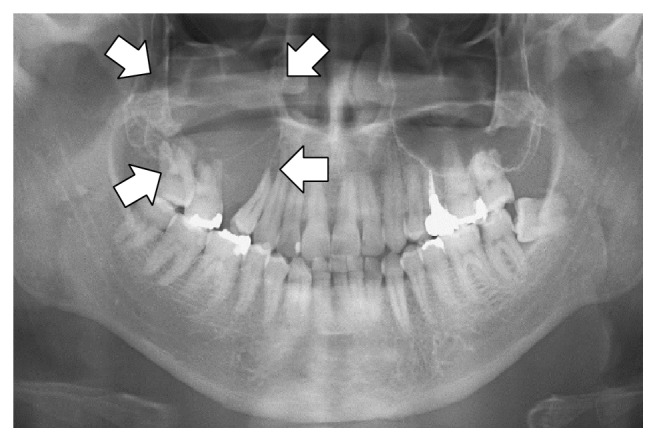

In [16]:
image

### Saving and Merge to float16 for VLLM

در این بخش شما باید وزن آنها لورا که آموزش دیده اند با وزن های مدل که فریز بودند در بخش آموزش ترکیب کنید تا وزنهای کلی مدل آموزش داده شود. این کار با یک دستور تک خطی کوتاه امکان پذیر است. اجرای این دستور ممکن است چند دقیقه طول بکشد. این دستور یکی از دستورات ذخیره وزن های مدل هست که وزن ها را باهم ترکیب و در حافظه ذخیره میکند و شما میتوانید هر زمان به مدل آموزش داده خود دسترسی داشته باشید.

In [17]:
model.save_pretrained("lora_adapter")
tokenizer.save_pretrained("lora_adapter")

[]

In [19]:
model.save_pretrained_merged(
    "qwen2vl_radiology_model",
    tokenizer,
    save_method="merged_16bit",
)# Complete from here

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [02:42<00:00, 162.46s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [02:07<00:00, 127.01s/it]


Unsloth: Merge process complete. Saved to `/content/qwen2vl_radiology_model`


In [20]:
from google.colab import drive
drive.mount('/content/drive')

model.save_pretrained("/content/drive/MyDrive/final_model")
tokenizer.save_pretrained("/content/drive/MyDrive/final_model")

Mounted at /content/drive


[]